In [1]:
!pip install pandas


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install requests


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import requests
import pandas as pd

load_url = "https://api-v3.thaiwater.net/api/v1/thaiwater30/public/waterlevel_load"
headers = {"User-Agent": "Mozilla/5.0", "Accept": "application/json"}

payload = requests.get(load_url, headers=headers, timeout=30).json()

stations = payload["waterlevel_data"]["data"]
df_stations = pd.json_normalize(stations)

# Keep only what we need
cols = ["id", "station_type", "station.tele_station_name.th"]
keep = [c for c in cols if c in df_stations.columns]
df_stations = df_stations[keep].drop_duplicates()

print(df_stations.head())
df_stations.to_csv("thaiwater_station_list.csv", index=False, encoding="utf-8-sig")
print("Saved thaiwater_station_list.csv, rows:", len(df_stations))

           id     station_type station.tele_station_name.th
0  1248011307  tele_waterlevel              บ้านขนงพระเหนือ
1  1248017722  tele_waterlevel   สะพานธรรมจักร(วัดธรรมามูล)
2  1247993384  tele_waterlevel         ที่ว่าการอ.นครชัยศรี
3  1248017530  tele_waterlevel           สะพานแม่น้ำแควใหญ่
4  1247993388  tele_waterlevel                วัดบางไผ่นารถ
Saved thaiwater_station_list.csv, rows: 759


In [5]:
import re
import requests
import pandas as pd
from time import sleep

LOAD_URL = "https://api-v3.thaiwater.net/api/v1/thaiwater30/public/waterlevel_load"
GRAPH_URL = "https://api-v3.thaiwater.net/api/v1/thaiwater30/public/waterlevel_graph_year"
HEADERS = {"User-Agent": "Mozilla/5.0", "Accept": "application/json"}

YEARS = range(2024, 2027)   # keep small while testing
N = 5                       # run only first N stations


def looks_numeric(x) -> bool:
    if x is None:
        return False
    s = str(x).strip()
    return bool(re.fullmatch(r"\d{4,}", s))  # 4+ digits


# 1) Load station list
payload = requests.get(LOAD_URL, headers=HEADERS, timeout=30).json()
stations = payload["waterlevel_data"]["data"]
df_stations = pd.json_normalize(stations)

# 2) Find candidate numeric columns (station.* and top-level)
candidates = []
for c in df_stations.columns:
    if "name" in c.lower():
        continue
    sample = df_stations[c].dropna().astype(str).head(30)
    if len(sample) and any(looks_numeric(v) for v in sample):
        candidates.append(c)

print("Numeric-looking columns:", candidates)

# 3) Pick a station_type that supports graph endpoint (tele_waterlevel is known to work)
# Filter to tele_waterlevel rows if available
df_probe = df_stations[df_stations["station_type"] == "tele_waterlevel"].copy()
if df_probe.empty:
    df_probe = df_stations.copy()

if "station_type" in df_probe.columns:
    df_tele = df_probe[df_probe["station_type"] == "tele_waterlevel"].copy()
    if not df_tele.empty:
        df_probe = df_tele

if df_probe.empty:
    raise RuntimeError("Station list is empty (waterlevel_load returned no stations).")

probe_row = df_probe.iloc[0]
probe_station_type = probe_row.get("station_type", "tele_waterlevel") 

def test_candidate(col: str):
    v = probe_row.get(col)
    if not looks_numeric(v):
        return None

    station_id = str(v).strip()
    params = {"station_type": probe_station_type, "station_id": station_id, "year": "2026"}

    r = requests.get(GRAPH_URL, params=params, headers=HEADERS, timeout=30)
    if r.status_code != 200:
        return None

    try:
        j = r.json()
    except Exception:
        return None

    if j.get("result") == "OK" and j.get("data", {}).get("graph_data"):
        return station_id
    return None

graph_id_col = None
for col in candidates:
    ok_id = test_candidate(col)
    if ok_id:
        graph_id_col = col
        print("✅ Found graph station id column:", graph_id_col, "example:", ok_id)
        break

if not graph_id_col:
    raise RuntimeError(
        "Could not auto-detect the graph station id column.\n"
        "Please print `candidates` and show df_stations.head(1).to_dict()"
    )

# 4) Build run list (tele_waterlevel only is safest)
df_run = df_stations[df_stations["station_type"] == "tele_waterlevel"].copy()
df_run = df_run[df_run[graph_id_col].apply(looks_numeric)].copy()

print(f"\nRunning first {len(df_run)} stations using {graph_id_col}")

all_rows = []

for i, (_, row) in enumerate(df_run.iterrows(), start=1):
    station_type = row["station_type"]
    station_id = str(row[graph_id_col]).strip()
    station_name = row.get("station.tele_station_name.th", row.get("station_name", ""))

    print(f"\n[{i}/{len(df_run)}] station_id={station_id} name={station_name}")

    for year in YEARS:
        params = {"station_type": station_type, "station_id": station_id, "year": str(year)}
        r = requests.get(GRAPH_URL, params=params, headers=HEADERS, timeout=30)

        if r.status_code != 200:
            print(" year", year, "status", r.status_code)
            continue

        p = r.json()

        if isinstance(p, str):
            print(f" ⚠️ Warning: API returned a string instead of JSON for station {station_id}")
            continue
        
        gd = p.get("data", {}).get("graph_data", [])
        if not gd:
            continue

        year_entry = next((x for x in gd if str(x.get("year")) == str(year)), None)
        if not year_entry or not year_entry.get("data"):
            continue

        df = pd.DataFrame(year_entry["data"])
        if df.empty:
            continue

        df["ds"] = pd.to_datetime(df["datetime"], errors="coerce")

        # prefer waterlevel_msl, fallback waterlevel_m
        if "waterlevel_msl" in df.columns and df["waterlevel_msl"].notna().any():
            df["y"] = pd.to_numeric(df["waterlevel_msl"], errors="coerce")
        else:
            df["y"] = pd.to_numeric(df.get("waterlevel_m"), errors="coerce")

        df["station_id"] = station_id
        df["station_type"] = station_type
        df["station_name_th"] = station_name
        df["year"] = year

        df = df.dropna(subset=["ds", "y"])

        if not df.empty:
            all_rows.append(df[["station_id", "station_type", "station_name_th", "ds", "y", "year"]])

        sleep(0.3)

if not all_rows:
    raise RuntimeError("No data collected. Try changing YEARS or N.")

ts_all = pd.concat(all_rows, ignore_index=True).sort_values(["station_id", "ds"]).reset_index(drop=True)
out = f"thaiwater_first_{len(df_run)}_stations_history.csv"
ts_all.to_csv(out, index=False, encoding="utf-8-sig")
print("\nSaved:", out, "rows:", len(ts_all))


Numeric-looking columns: ['id', 'station.id', 'station.geocode_id']
✅ Found graph station id column: station.id example: 1117894

Running first 566 stations using station.id

[1/566] station_id=1117894 name=บ้านขนงพระเหนือ

[2/566] station_id=2676 name=ที่ว่าการอ.นครชัยศรี

[3/566] station_id=1121258 name=สะพานแม่น้ำแควใหญ่

[4/566] station_id=528052 name=วัดบางไผ่นารถ

[5/566] station_id=1095877 name=บ้านหัวสะพาน

[6/566] station_id=505041 name=ร.ร.บ้านสามพราน

[7/566] station_id=1093079 name=คลองชะอวด

[8/566] station_id=2599 name=กรมชลประทานสามเสน

[9/566] station_id=505039 name=บ้านบางการ้อง

[10/566] station_id=1085210 name=สะพานตาบัว บ้านยาเด๊ะ

[11/566] station_id=1095849 name=สะพานหัวเวียง

[12/566] station_id=1130137 name=น้ำตกโตนแพรทอง

[13/566] station_id=1161516 name=บ้านหาดทรายแก้ว 

[14/566] station_id=1082427 name=บ่อดินขาว

[15/566] station_id=2575 name=ประปายโสธร

[16/566] station_id=1109526 name=สะพานข้ามคลองอู่ตะเภา

[17/566] station_id=726673 name=บ้านนาสีทอง

[18/5

ReadTimeout: HTTPSConnectionPool(host='api-v3.thaiwater.net', port=443): Read timed out. (read timeout=30)

In [ ]:
import pandas as pd


path = "thaiwater_first_5_stations_history.csv"
df = pd.read_csv(path)

df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values(["station_id", "ds"]).reset_index(drop=True)

print(df.head())
print(df.dtypes)
print("stations:", df["station_id"].nunique())
print(df["station_id"].unique()[:10])

   station_id     station_type       station_name_th                  ds  \
0      575566  tele_waterlevel  ปตร.วัดบางกระเจ้านอก 2024-01-01 06:00:00   
1      575566  tele_waterlevel  ปตร.วัดบางกระเจ้านอก 2024-01-03 06:00:00   
2      575566  tele_waterlevel  ปตร.วัดบางกระเจ้านอก 2024-01-04 06:00:00   
3      575566  tele_waterlevel  ปตร.วัดบางกระเจ้านอก 2024-01-05 06:00:00   
4      575566  tele_waterlevel  ปตร.วัดบางกระเจ้านอก 2024-01-06 06:00:00   

      y  year  
0  0.13  2024  
1 -0.10  2024  
2  0.04  2024  
3  0.52  2024  
4  0.65  2024  
station_id                  int64
station_type                  str
station_name_th               str
ds                 datetime64[us]
y                         float64
year                        int64
dtype: object
stations: 5
[ 575566  575567  575568  575569 1117894]


In [ ]:
station_id = df["station_id"].iloc[0]  # pick first
df1 = df[df["station_id"] == station_id].copy()

df1 = df1[["ds", "y"]].dropna()
df1 = df1.sort_values("ds")

print("station:", station_id, "rows:", len(df1))
df1.head()

station: 575566 rows: 833


,ds,y
0,2024-01-01 06:00:00,0.13
1,2024-01-03 06:00:00,-0.10
2,2024-01-04 06:00:00,0.04
3,2024-01-05 06:00:00,0.52
4,2024-01-06 06:00:00,0.65


In [ ]:
# Use date only (daily)
ts = df1.copy()
ts["date"] = ts["ds"].dt.floor("D")
ts = ts.groupby("date", as_index=False)["y"].mean()

ts = ts.set_index("date").asfreq("D")
# Fill missing values (simple interpolation)
ts["y"] = ts["y"].interpolate(limit_direction="both")

ts.head(), ts.tail()

(                y
 date             
 2024-01-01  0.130
 2024-01-02  0.015
 2024-01-03 -0.100
 2024-01-04  0.040
 2024-01-05  0.520,
                y
 date            
 2026-05-19  1.29
 2026-05-20  1.27
 2026-05-21  1.43
 2026-05-22  1.29
 2026-05-23  0.99)

In [ ]:
def make_features(ts_df):
    x = ts_df.copy()
    x["lag_1"]  = x["y"].shift(1)
    x["lag_2"]  = x["y"].shift(2)
    x["lag_3"]  = x["y"].shift(3)
    x["lag_7"]  = x["y"].shift(7)
    x["lag_14"] = x["y"].shift(14)

    x["roll_7_mean"]  = x["y"].shift(1).rolling(7).mean()
    x["roll_14_mean"] = x["y"].shift(1).rolling(14).mean()

    # Optional calendar features
    x["dow"] = x.index.dayofweek
    x["month"] = x.index.month
    return x

feat = make_features(ts)
feat = feat.dropna()

X = feat.drop(columns=["y"])
y = feat["y"]

X.head(), y.head()

(            lag_1  lag_2  lag_3  lag_7  lag_14  roll_7_mean  roll_14_mean  \
 date                                                                        
 2024-01-15   0.62   1.14   1.47   1.43   0.130     1.358571      0.832500   
 2024-01-16   0.24   0.62   1.14   1.58   0.015     1.188571      0.840357   
 2024-01-17   0.05   0.24   0.62   1.62  -0.100     0.970000      0.842857   
 2024-01-18   0.20   0.05   0.24   1.65   0.040     0.767143      0.864286   
 2024-01-19   0.10   0.20   0.05   1.47   0.520     0.545714      0.868571   
 
             dow  month  
 date                    
 2024-01-15    0      1  
 2024-01-16    1      1  
 2024-01-17    2      1  
 2024-01-18    3      1  
 2024-01-19    4      1  ,
 date
 2024-01-15    0.24
 2024-01-16    0.05
 2024-01-17    0.20
 2024-01-18    0.10
 2024-01-19    0.37
 Freq: D, Name: y, dtype: float64)

In [ ]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

split_date = feat.index.max() - pd.Timedelta(days=60)  # last 60 days as test
train = feat[feat.index <= split_date]
test  = feat[feat.index >  split_date]

X_train, y_train = train.drop(columns=["y"]), train["y"]
X_test, y_test   = test.drop(columns=["y"]),  test["y"]

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

MAE: 0.09072172222222262


In [ ]:
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


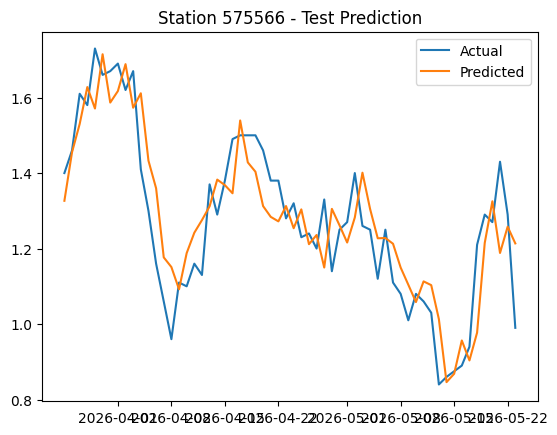

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, pred, label="Predicted")
plt.title(f"Station {station_id} - Test Prediction")
plt.legend()
plt.show()

In [ ]:
import numpy as np

def forecast_next_days(ts_daily, model, days=7):
    ts_future = ts_daily.copy()

    for _ in range(days):
        feat = make_features(ts_future)[-1:]   # last row features
        feat = feat.drop(columns=["y"], errors="ignore")
        yhat = model.predict(feat)[0]

        next_day = ts_future.index.max() + pd.Timedelta(days=1)
        ts_future.loc[next_day, "y"] = yhat

    return ts_future

ts_forecasted = forecast_next_days(ts, model, days=7)

future_part = ts_forecasted.tail(7)
future_part

,y
date,
2026-05-24,1.21366
2026-05-25,0.98463
2026-05-26,1.16994
2026-05-27,0.96662
2026-05-28,0.98330
2026-05-29,0.86596
2026-05-30,0.84900
